In [1]:
# ==========================================================
# Carrera de Ingeniería de Sistemas
# Universidad Franz Tamayo
# ----------------------------------------------------------
#                       Asignatura: MINERIA DE DATOS
# ----------------------------------------------------------
#        Enrique Alejandro Laurel Cossio, Abril 2026
# ==========================================================
#        Regresión Lineal Simple y Múltiple
# ==========================================================

# REGRESIÓN LINEAL - REGRESIÓN

## 🌳 Concepto básico
- **Definición:** La regresión lineal busca modelar la relación entre una variable dependiente continua (ej. costos hospitalarios, ingresos, tiempo de espera) y una o varias variables independientes.  
- **Objetivo:** Estimar cómo cambia la variable objetivo cuando cambian las variables explicativas.  
- **Ecuación general:**  

  $Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \dots + \beta_n X_n + \varepsilon$

  donde:
  - \(Y\): variable objetivo (continua).  
  - \($\beta_0$\): intercepto.  
  - \($\beta_i$\): coeficientes o parámetros asociados a cada variable independiente.  
  - \($\varepsilon$\): error aleatorio.

---

## 📊 Interpretación de los parámetros (\($\beta$\))
- **Signo del coeficiente:**
  - **Positivo:** indica que al aumentar la variable independiente, la variable objetivo también tiende a aumentar.  
  - **Negativo:** indica que al aumentar la variable independiente, la variable objetivo tiende a disminuir.  

- **Magnitud del coeficiente:** refleja cuánto cambia la variable objetivo por cada unidad de cambio en la variable independiente, manteniendo las demás constantes.  

### Ejemplo aplicado (costo hospitalario):
Supongamos que queremos predecir el **costo hospitalario** (\($Y$\)) en función de:
- **Edad del paciente** (\($X_1$\))  
- **Días de hospitalización** (\($X_2$\))  

El modelo estimado es:  
\[
$Costo = 500 + 20 \cdot Edad + 150 \cdot Días$
\]

Interpretación:
- **Intercepto (500):** costo base cuando edad y días = 0 (valor de referencia).  
- **Edad (20):** cada año adicional del paciente incrementa en promedio 20 unidades monetarias el costo hospitalario.  
- **Días (150):** cada día adicional de hospitalización incrementa en promedio 150 unidades monetarias el costo.  

---

## 📏 P-valores de los parámetros
- El **p-valor** indica si el coeficiente \($\beta_i$\) es estadísticamente significativo.  
- **Regla práctica:**  
  - Si \($p < 0.05$\): el coeficiente es significativo, la variable tiene efecto real sobre la variable objetivo.  
  - Si \($p \geq 0.05$\): no hay evidencia suficiente para afirmar que la variable influye en la variable objetivo.  

Ejemplo:  
- Si el p-valor de “Edad” es 0.001 → altamente significativo.  
- Si el p-valor de “Días” es 0.20 → no significativo, podría no aportar valor al modelo.

---

## 📏 Medidas de ajuste del modelo
- **R² (Coeficiente de determinación):** proporción de la variabilidad de \($Y$\) explicada por el modelo.  
  - Ejemplo: R² = 0.80 → el 80% de la variabilidad en costos hospitalarios se explica por edad y días.  
- **MSE (Error cuadrático medio):** promedio de los errores al cuadrado. Penaliza más los errores grandes.  
- **MAE (Error absoluto medio):** promedio de los errores absolutos, más robusto frente a valores extremos.  
- **AIC/BIC:** criterios de información para comparar modelos, penalizan la complejidad.
|
---

## ✅ Ventajas
- Fácil de interpretar y explicar en clase.  
- Permite cuantificar el efecto de cada variable independiente.  
- Base para modelos más complejos (regresión múltiple, regularización, etc.).  
- Útil en escenarios prácticos como **business analytics** y **hospital accounting**.

## ⚠️ Desventajas
- Supone **linealidad** entre variables.  
- Sensible a **multicolinealidad** (correlación alta entre variables independientes).  
- Puede ser afectado por **outliers**.  
- No captura relaciones no lineales sin transformaciones adicionales.

---

## 📌 Checklist para entrenar un modelo de regresión lineal
1. **Definir la variable objetivo** (continua).  
2. **Seleccionar variables independientes** relevantes.  
3. **Dividir dataset** en entrenamiento y prueba.  
4. **Entrenar modelo** y obtener coeficientes (\($\beta$\)).  
5. **Interpretar coeficientes y p-valores.**  
6. **Evaluar métricas de ajuste** (R², MSE, RMSE, MAE).  
7. **Validar supuestos**: linealidad, homocedasticidad, normalidad de residuos. (de conocimiento) 
8. **Comunicar resultados** con ejemplos prácticos y visualizaciones.

# 1. LIBRERIAS Y FUNCIONES

In [64]:
# Cargamos Librerias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# modelo de regresion lineal
import statsmodels.api as sm
import statsmodels.formula.api as smf
import statsmodels.stats.api as sms

# train test
from sklearn.model_selection import train_test_split

from sklearn.metrics import accuracy_score,mean_squared_error,r2_score,confusion_matrix,recall_score,classification_report,precision_score,f1_score


# 2. PARAMETRIZACIÓN

# 3. DATOS

In [3]:
# cargamos datos
seguros = pd.read_csv('data/insurance.csv',sep=',', encoding='iso-8859-1')
print(seguros.shape) #
seguros.head(2)

(1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.90,0,yes,southwest,16884.9240
1,18,male,33.77,1,no,southeast,1725.5523


Detalle de las variables
- age: Edad
- sex: sexo
- bmi: indices de masa corporal(para evaluar el riesgo de salud del asegurado)
- children: número de hijos
- smoker: fumador
- region: area donde habita
- chargues: costo del seguro



# 4. PROCESO

## 4.1. EDA - Análisis exploratorio de datos

In [4]:
# Exploración de datos
# tipo de datos
seguros.dtypes

age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

In [5]:
seguros.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


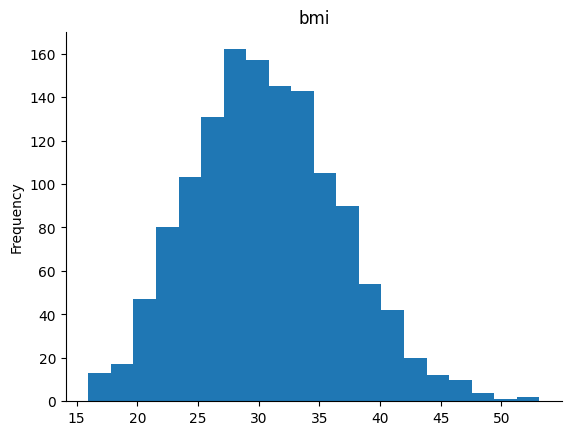

In [6]:
from matplotlib import pyplot as plt
seguros['bmi'].plot(kind='hist', bins=20, title='bmi')
plt.gca().spines[['top', 'right',]].set_visible(False)

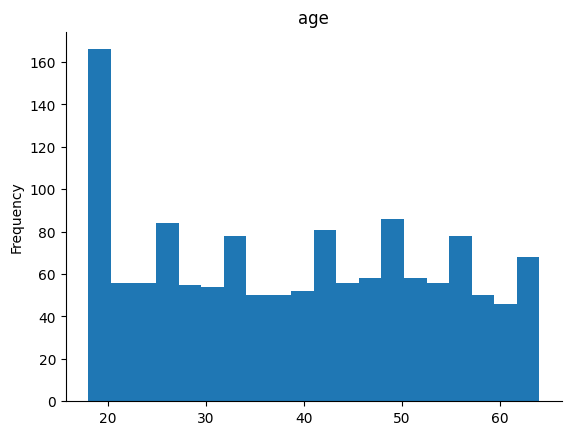

In [7]:
from matplotlib import pyplot as plt
seguros['age'].plot(kind='hist', bins=20, title='age')
plt.gca().spines[['top', 'right',]].set_visible(False)

In [ ]:
# una copia de la fuente de datos
df = seguros.copy()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [ ]:
# codificamos las variables
#df['sex'].replace({'male':0, 'female': 1}, inplace=True)
#df['smoker'].replace({'no':0, 'yes': 1}, inplace=True)
#df['region'].replace({'southwest':0, 'southeast': 1, 'northwest':2, 'northeast': 3}, inplace=True)

In [9]:
df.head(2)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.90,0,yes,southwest,16884.9240
1,18,male,33.77,1,no,southeast,1725.5523


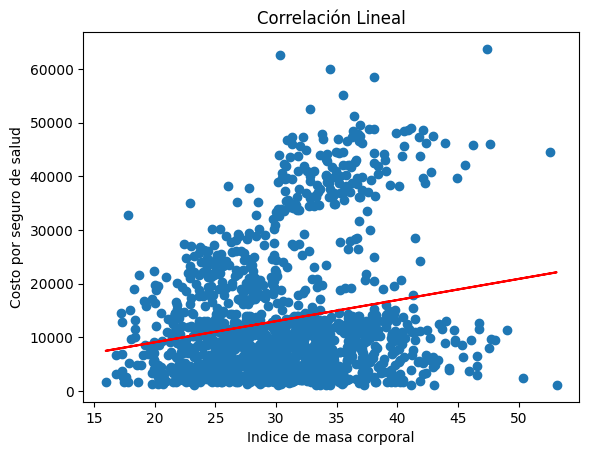

In [ ]:
# grafico de dispersión
plt.scatter(df.bmi, df.charges)
plt.title('Correlación Lineal')
plt.xlabel('Indice de masa corporal')
plt.ylabel('Costo por seguro de salud')
plt.grid(False)

# adicionamos una linea de regresión  Costo de seguro de salud vs Indice de masa corporal
slope, intercept = np.polyfit(df.bmi, df.charges, 1)
plt.plot(df.bmi, slope * df.bmi + intercept, color='red')

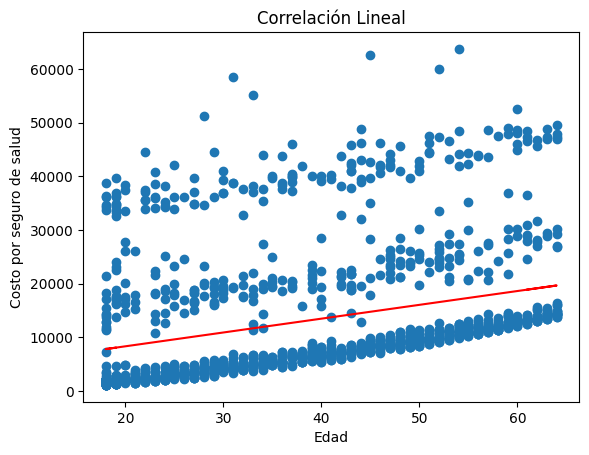

In [12]:
# grafico de dispersión
plt.scatter(df.age, df.charges)
plt.title('Correlación Lineal')
plt.xlabel('Edad')
plt.ylabel('Costo por seguro de salud')
plt.grid(False)

# adicionamos una linea de regresión  Costo de seguro de salud vs Indice de masa corporal
slope, intercept = np.polyfit(df.age, df.charges, 1)
plt.plot(df.age, slope * df.age + intercept, color='red')

In [58]:
df.head(2)

,age,bmi,children,charges,region_northeast,region_northwest,region_southeast,region_southwest,sex_female,sex_male,smoker_no,smoker_yes
0,19,27.90,0,16884.9240,0,0,0,1,1,0,0,1
1,18,33.77,1,1725.5523,0,0,1,0,0,1,1,0


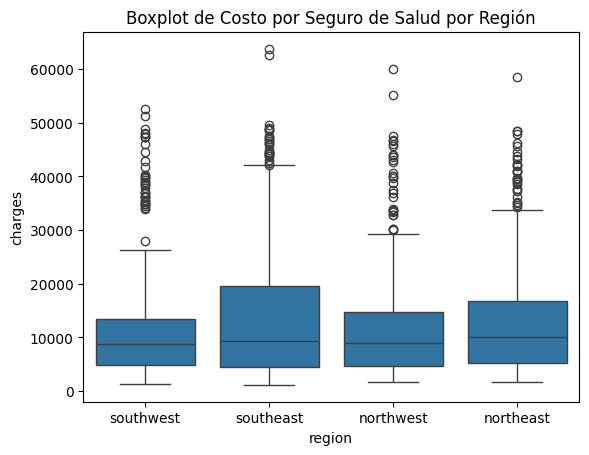

In [59]:
# grafico de boxplot del costo por seguro de salud por region
import seaborn as sns
sns.boxplot(x='region', y='charges', data=seguros)
plt.title('Boxplot de Costo por Seguro de Salud por Región')
plt.grid(False)
plt.show()

## 4.2. Modelo de Regresión

In [13]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

In [14]:
df.dtypes

age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

In [15]:
df.head(2)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.90,0,yes,southwest,16884.9240
1,18,male,33.77,1,no,southeast,1725.5523


In [16]:
df.region.unique()

<StringArray>
['southwest', 'southeast', 'northwest', 'northeast']
Length: 4, dtype: str

In [17]:
# a dummies las variables categoricas
df = pd.get_dummies(df, columns=['region'], drop_first=False)
print(df.shape)
df.head(2)

(1338, 10)


,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,female,27.90,0,yes,16884.9240,False,False,False,True
1,18,male,33.77,1,no,1725.5523,False,False,True,False


In [18]:
# a dummies
df = pd.get_dummies(df, columns=['sex','smoker'], drop_first=False)
print(df.shape)
df.head(2)

(1338, 12)


,age,bmi,children,charges,region_northeast,region_northwest,region_southeast,region_southwest,sex_female,sex_male,smoker_no,smoker_yes
0,19,27.90,0,16884.9240,False,False,False,True,True,False,False,True
1,18,33.77,1,1725.5523,False,False,True,False,False,True,True,False


In [20]:
# variables dummies  a entero
df = df.replace({True: 1, False: 0})

In [83]:
df.dtypes

age                   int64
bmi                 float64
children              int64
charges             float64
region_northeast     object
region_northwest     object
region_southeast     object
region_southwest     object
sex_female            int64
sex_male             object
smoker_no            object
smoker_yes           object
smorker_yes           int64
dtype: object

In [94]:
df['sex_female']=df['sex_female'].astype(int)
df['smoker_yes']=df['smoker_yes'].astype(int)
df['sex_male']=df['sex_male'].astype(int)

In [95]:
df.dtypes

age                   int64
bmi                 float64
children              int64
charges             float64
region_northeast     object
region_northwest     object
region_southeast     object
region_southwest     object
sex_female            int64
sex_male              int64
smoker_no            object
smoker_yes            int64
smorker_yes           int64
dtype: object

In [96]:
df.head(2)

,age,bmi,children,charges,region_northeast,region_northwest,region_southeast,region_southwest,sex_female,sex_male,smoker_no,smoker_yes,smorker_yes
0,19,27.90,0,16884.9240,0,0,0,1,1,0,0,1,1
1,18,33.77,1,1725.5523,0,0,1,0,0,1,1,0,0


In [97]:
# Definir las variables independientes y dependientes
#X = df[['age', 'sex_male', 'bmi', 'children', 'smoker_yes', 'region_northwest','region_southeast','region_southwest']]
X = df[['age', 'sex_male','smoker_yes', 'bmi', 'children']]
#X = df[['age', 'sex_female']]#, 'region_northeast','region_southeast','region_southwest']]
y = df['charges'] # variables dependiente

# Añadir una constante a las variables independientes
X = sm.add_constant(X) # relacionado intercepto

In [98]:
X.head()

,const,age,sex_male,smoker_yes,bmi,children
0,1.0,19,0,1,27.900,0
1,1.0,18,1,0,33.770,1
2,1.0,28,1,0,33.000,3
3,1.0,33,1,0,22.705,0
4,1.0,32,1,0,28.880,0


In [99]:
# División de conjunto de datos en entrenamiento y testeo
# train - test
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state =888 ) #Separamos 20% para test

In [100]:
print(X.shape)
X.head()

(1338, 6)


,const,age,sex_male,smoker_yes,bmi,children
0,1.0,19,0,1,27.900,0
1,1.0,18,1,0,33.770,1
2,1.0,28,1,0,33.000,3
3,1.0,33,1,0,22.705,0
4,1.0,32,1,0,28.880,0


In [101]:
print(x_train.shape) # el modelo entrena
print(x_test.shape) # evaluamos al modelo

(1070, 6)
(268, 6)


In [102]:
x_train.dtypes

const         float64
age             int64
sex_male        int64
smoker_yes      int64
bmi           float64
children        int64
dtype: object

In [103]:
# Ajustar el modelo de regresión lineal
modelo_OLS = sm.OLS(y_train, x_train).fit()

# Resumen del modelo
print(modelo_OLS.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.771
Model:                            OLS   Adj. R-squared:                  0.770
Method:                 Least Squares   F-statistic:                     717.8
Date:                Thu, 23 Apr 2026   Prob (F-statistic):               0.00
Time:                        14:13:37   Log-Likelihood:                -10823.
No. Observations:                1070   AIC:                         2.166e+04
Df Residuals:                    1064   BIC:                         2.169e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1.271e+04   1037.472    -12.253      0.0

In [42]:
# para ver la significancia de las variables independientes, se vera el p_valor
# a un valor de significacia alfa=0.05
# H0: B_i=0 # la variable X_i no aporta a la explicabilidad de Y
# H1: B_i!=0

# si p_valor<=alfa entonces se rechaza la hipotesis nula(H0)

tanto age como sex_female son variables significativas por el p valor de sus coeficientes asociados ya que su valor p_valor es menor a 0.05

In [104]:
df_train = pd.concat([pd.DataFrame(x_train),pd.DataFrame(y_train)], axis = 1)
print(df_train.shape)
df_train.head(2)

(1070, 7)


,const,age,sex_male,smoker_yes,bmi,children,charges
745,1.0,50,0,0,30.115,1,9910.35985
864,1.0,51,1,0,25.400,0,8782.46900


In [105]:
# Ajustando el modelo de regresion utilizando una formula:
resultados = smf.ols("charges ~ age ", data=df_train).fit()
#resultados = smf.ols("charges ~ age + sex_male + bmi + children + smoker_yes + region_northwest + region_southeast + region_southwest", data=df_train).fit()

# Resultados
print(resultados.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.089
Model:                            OLS   Adj. R-squared:                  0.088
Method:                 Least Squares   F-statistic:                     103.7
Date:                Thu, 23 Apr 2026   Prob (F-statistic):           2.57e-23
Time:                        14:13:45   Log-Likelihood:                -11563.
No. Observations:                1070   AIC:                         2.313e+04
Df Residuals:                    1068   BIC:                         2.314e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   3173.5915   1085.570      2.923      0.0

In [106]:
df_test = pd.concat([pd.DataFrame(x_test),pd.DataFrame(y_test)], axis = 1)
print(df_test.shape)
df_test.head(2)

(268, 7)


,const,age,sex_male,smoker_yes,bmi,children,charges
1121,1.0,46,1,0,38.17,2,8347.1643
671,1.0,29,0,0,31.16,0,3943.5954


In [107]:
# Realizar predicciones sobre el conjunto de testeo A
y_pred = modelo_OLS.predict(sm.add_constant(x_test))
y_pred

1121    12893.990972
671      5474.218391
121        16.262589
1011    30406.562935
894     14346.150301
            ...     
108      4314.424612
382     12822.982110
212      3858.028723
2        6764.048359
1277     5771.350599
Length: 268, dtype: float64

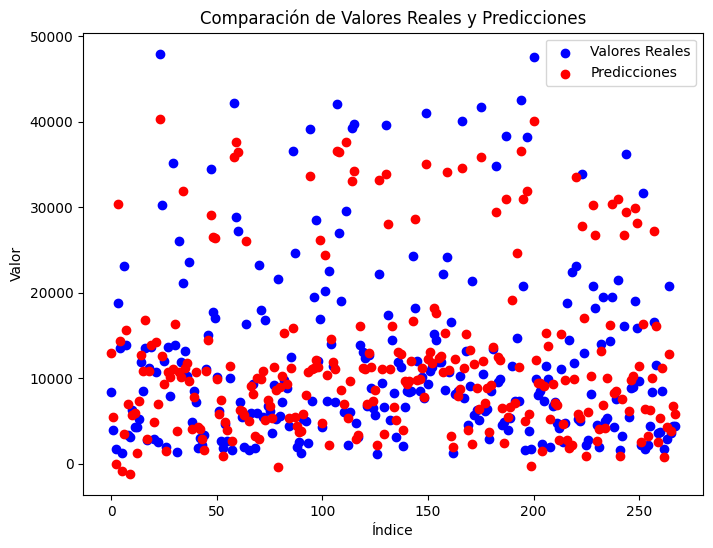

In [108]:
# Graficar los valores reales vs predicciones
plt.figure(figsize=(8,6))
plt.scatter(range(len(x_test)), y_test, color='blue', label='Valores Reales')
plt.scatter(range(len(x_test)), y_pred, color='red', label='Predicciones')
plt.xlabel('Índice')
plt.ylabel('Valor')
plt.title('Comparación de Valores Reales y Predicciones')
plt.legend()
plt.show()


In [109]:
# Evaluación del modelo
print("MSE:", mean_squared_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))

MSE: 40958721.37108739
R²: 0.6121902626950781


## 4.3. Supuestos del Modelo (opcional)

In [44]:
# Test de normalidad de residuos: Jarque-Bera
test = sms.jarque_bera(modelo_OLS.resid)
print(f'Estadígrafo Jarque-Bera (JB): {test[0]}')
print(f'p-value JB ~ chi^2(2): {test[1]}')
print(f'Sesgo: {test[2]}')
print(f'Curtosis: {test[3]}')
# Hipotesis Nula: Normalidad

# si p_valor<=0.05 entonces se rechaza hipotesis Nula

Estadígrafo Jarque-Bera (JB): 622.9567056982787
p-value JB ~ chi^2(2): 5.329299470163376e-136
Sesgo: 1.6731657110824714
Curtosis: 4.665811124224795


In [ ]:
# Test Homocedasticidad: Breusch–Pagan
test = sms.het_breuschpagan(modelo_OLS.resid, modelo_OLS.model.exog)
#print(f'Estadígrafo LMBP: {test[0]}')
#print(f'p-value LMBP ~ chi^2(k-1): {test[1]}')
print(f'Estadígrafo FBP: {test[2]}')
print(f'p-value FBP ~ F(k,n-k-1): {test[3]}')
# Hipotesis Nula: Homocedasticidad

# si p_valor<=0.05 entonces se rechaza la hipotesis nula
# ¿ 0.01<=0.05 ? , entonces  rechazamos la hipotesis nula

Estadígrafo FBP: 4.255289125252371
p-value FBP ~ F(k,n-k-1): 0.014430541743816479


In [46]:
x_train.shape

(1070, 3)

In [47]:
# Correlacion de los errores: Test de Durbin-Watson
from statsmodels.stats.stattools import durbin_watson
from scipy.stats import norm
dw_stat = durbin_watson(modelo_OLS.resid)
print(f'Estadística de Durbin-Watson: {dw_stat}')
# Interpretación basada en valores críticos (asumiendo un nivel de significancia de 0.05)
# Nota: Los valores críticos dL y dU dependen de n y k
dL = 1.758 # Valor crítico inferior
dU = 1.778  # Valor crítico superior
if dw_stat < dL:
    print("Evidencia de autocorrelación positiva de primer orden")
elif dL <= dw_stat <= dU:
    print("Prueba inconclusa.")
else:
    print("No hay evidencia de autocorrelación positiva.")

Estadística de Durbin-Watson: 2.070670454483859
No hay evidencia de autocorrelación positiva.


In [48]:
dw_stat

np.float64(2.070670454483859)

In [49]:
# *** Evaluando multicolinealidad: VIF ***
from statsmodels.stats.outliers_influence import variance_inflation_factor
# VIF para cada variable
vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]


#VIF ≥ 10: multicolinealidad severa
#VIF ≥ 5: multicolinealidad elevada
#VIF < 5: multicolinealidad débil a moderad
print(vif_data)

     Variable       VIF
0       const  9.660784
1         age  1.000435
2  sex_female  1.000435


# 4. Transformación de variables

In [50]:
df_train.charges.describe()

count     1070.000000
mean     13586.389990
std      12507.656883
min       1121.873900
25%       4746.521225
50%       9523.002925
75%      17166.118320
max      63770.428010
Name: charges, dtype: float64

In [51]:
# los datos de costo del seguro se encuentran entre
df_train.charges.mean()-3*df_train.charges.std(), df_train.charges.mean()+3*df_train.charges.std()

(np.float64(-23936.580658559586), np.float64(51109.3606376979))

In [52]:
#
df_train_2=df_train.copy()

In [53]:
# creamos la variable logaritmo
df_train_2['log_charges']=np.log(df_train_2.charges)

In [54]:
df_train_2.log_charges.describe()

count    1070.000000
mean        9.113207
std         0.930125
min         7.022756
25%         8.465167
50%         9.161464
75%         9.750692
max        11.063045
Name: log_charges, dtype: float64

In [55]:
# Ajustando el modelo de regresion utilizando una formula y transformación en la variable respuesta:
resultados = smf.ols("charges ~ age ", data=df_train).fit()
#resultados = smf.ols("charges ~ age + sex_male + region_northwest + region_southeast + region_southwest", data=df_train).fit()

# + bmi + children + smoker_yes + region_northwest + region_southeast + region_southwest
# Resultados
print(resultados.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.089
Model:                            OLS   Adj. R-squared:                  0.088
Method:                 Least Squares   F-statistic:                     103.7
Date:                Thu, 23 Apr 2026   Prob (F-statistic):           2.57e-23
Time:                        14:06:27   Log-Likelihood:                -11563.
No. Observations:                1070   AIC:                         2.313e+04
Df Residuals:                    1068   BIC:                         2.314e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   3173.5915   1085.570      2.923      0.0

In [56]:
# Test Homocedasticidad: Breusch–Pagan
test = sms.het_breuschpagan(resultados.resid, resultados.model.exog)
print(f'Estadígrafo LMBP: {test[0]}')
print(f'p-value LMBP ~ chi^2(k-1): {test[1]}')
print(f'Estadígrafo FBP: {test[2]}')
print(f'p-value FBP ~ F(k,n-k-1): {test[3]}')
# Hipotesis Nula: Homocedasticidad

Estadígrafo LMBP: 0.00020748248515611856
p-value LMBP ~ chi^2(k-1): 0.9885074668747503
Estadígrafo FBP: 0.00020709470761243073
p-value FBP ~ F(k,n-k-1): 0.9885208984683573
